In [1]:
!git clone https://github.com/instar94/ml_note.git
%cd ml_note
%run env_setup.py

Cloning into 'ml_note'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 92 (delta 34), reused 43 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (92/92), 1.33 MiB | 11.53 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/ml_note
[env_setup] 환경: colab | 한글 폰트 설정 완료


In [27]:
# ── Colab 한글 폰트 설정 (1회만 실행) ────────────
import subprocess
subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료")

한글 폰트 설정 완료


# 1. 데이터셋 세팅
## 데이터셋 소개
### 추천 데이터셋: Red Wine Quality
https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

### 변수 소개
Input variables (based on physicochemical tests):

  - 1 - fixed acidity
  - 2 - volatile acidity
  - 3 - citric acid
  - 4 - residual sugar
  - 5 - chlorides
  - 6 - free sulfur dioxide
  - 7 - total sulfur dioxide
  - 8 - density
  - 9 - pH
  - 10 - sulphates
  - 11 - alcohol

Output variable (based on sensory data):

  - 12 - quality (score between 0 and 10)

# 2. 데이터 로드 및 확인

## 데이터 다운로드

In [2]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)

100%|██████████| 25.6k/25.6k [00:00<00:00, 10.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2


### 데이터를 파이썬으로 로드

In [6]:
## 데이터를 파이썬으로 로드
import os
import zipfile
#import kaggle
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parents[1]
DATA_DIR = path

print("프로젝트 루트:", PROJECT_ROOT)
print("저장 경로   :", DATA_DIR)

print(os.listdir(DATA_DIR))

프로젝트 루트: /
저장 경로   : /root/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2
['winequality-red.csv']


### 데이터셋 확인
  - 1599샘플, 특성 11개, 타겟 quality (3~8)
  - quality 5, 6에 집중 → 불균형 있음
  - 결측치 없어 보임

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# kagglehub 캐시 경로 직접 지정
DATA_PATH = "/root/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2/winequality-red.csv"

data = pd.read_csv(DATA_PATH, sep=",")
print(data.shape)
print(data.head())
print(data["quality"].value_counts().sort_index())

(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.

### EDA

#### 기초통계 확인
  - 결측치 없음

In [14]:
# 결측치 & 기초 통계
print("=== 결측치 ===")
print(data.isnull().sum())

print("\n=== 기초 통계 ===")
print(data.describe())

=== 결측치 ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

=== 기초 통계 ===
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

        

- 대략적인 상관관계 보기
  - 높은 상관 관계 :
    -  alcohol(+0.48)
    - volatile acidity(-0.39)
    - sulphates(+0.25)
  - 다중공선성 주의 쌍:
    - fixed acidity↔citric acid(0.67)
    - fixed acidity↔density(0.67)
    - free SO2↔total SO2(0.67)
    - → Ridge/Lasso에서 효과 볼 특성들

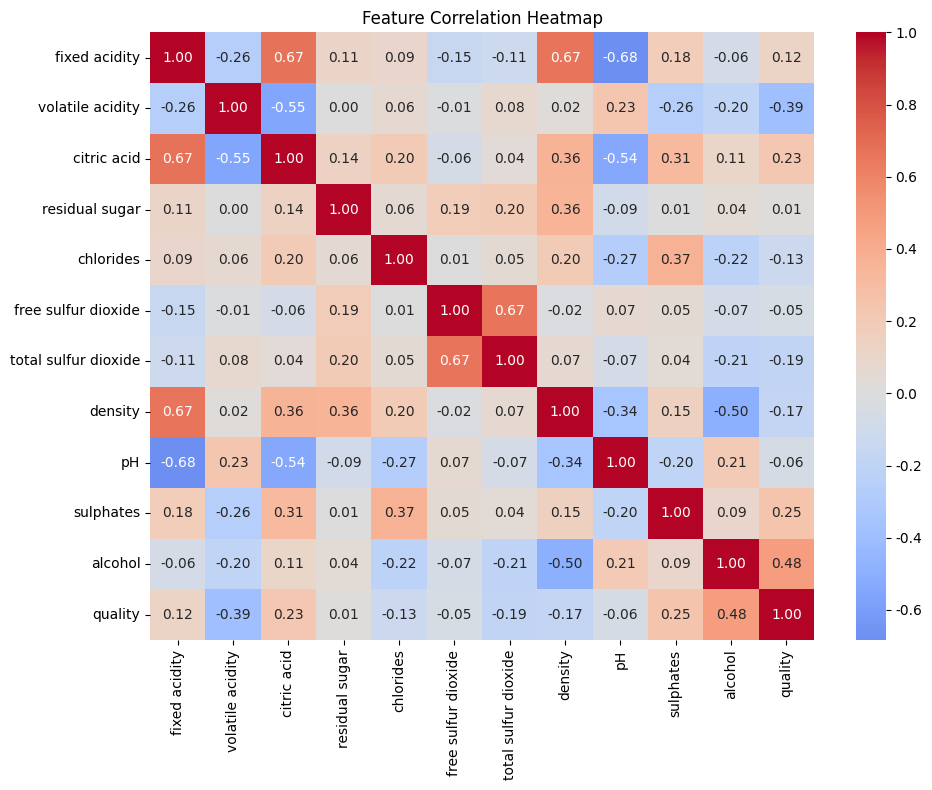

In [15]:

# 상관관계 히트맵
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 선형회귀를 통한 모델 학습
  - 정규 방정식을 직접 계산

### 결과 해석
  - volatile acidity(-1.00): 휘발성 산도가 높을수록 품질 하락
  - density(-10.35): 밀도가 높을수록 품질 하락
  - sulphates(+0.84), alcohol(+0.28): 품질에 긍정적
  - chlorides(-1.81): 염화물 높으면 품질 하락

In [16]:

from sklearn.preprocessing import add_dummy_feature

# 타겟 / 특성 분리
X = data.drop("quality", axis=1).values   # (1599, 11)
y = data["quality"].values.reshape(-1, 1)  # (1599, 1)

# 훈련/테스트 분리 (먼저 해두기)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("훈련 세트:", X_train.shape, y_train.shape)
print("테스트 세트:", X_test.shape, y_test.shape)

# ── 정규방정식 직접 구현 ──────────────────────
# θ^ = (X^T X)^(-1) X^T y
X_train_b = add_dummy_feature(X_train)   # x0=1 편향 추가

theta_best = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

print("\n=== 정규방정식으로 구한 θ ===")
feature_names = ["bias"] + list(data.drop("quality", axis=1).columns)
for name, theta in zip(feature_names, theta_best.flatten()):
    print(f"  {name:25s}: {theta:.4f}")

훈련 세트: (1279, 11) (1279, 1)
테스트 세트: (320, 11) (320, 1)

=== 정규방정식으로 구한 θ ===
  bias                     : 14.3551
  fixed acidity            : 0.0231
  volatile acidity         : -1.0013
  citric acid              : -0.1408
  residual sugar           : 0.0066
  chlorides                : -1.8065
  free sulfur dioxide      : 0.0056
  total sulfur dioxide     : -0.0036
  density                  : -10.3516
  pH                       : -0.3937
  sulphates                : 0.8412
  alcohol                  : 0.2819


- sklearn을 이용한 방식과 비교
  -$RMES$가 동일

In [17]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ── sklearn LinearRegression ──────────────────
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("=== sklearn θ 비교 ===")
print(f"{'특성':<25} {'정규방정식':>10} {'sklearn':>10} {'차이':>10}")
print("-" * 58)
print(f"{'bias':<25} {theta_best[0,0]:>10.4f} {lin_reg.intercept_[0]:>10.4f} {abs(theta_best[0,0]-lin_reg.intercept_[0]):>10.6f}")
for name, t, s in zip(data.drop("quality",axis=1).columns,
                       theta_best[1:].flatten(),
                       lin_reg.coef_[0]):
    print(f"{name:<25} {t:>10.4f} {s:>10.4f} {abs(t-s):>10.6f}")

# ── RMSE 평가 ──────────────────────────────────
X_test_b = add_dummy_feature(X_test)

# 정규방정식 예측
y_pred_normal = X_test_b @ theta_best
rmse_normal = np.sqrt(mean_squared_error(y_test, y_pred_normal))

# sklearn 예측
y_pred_sklearn = lin_reg.predict(X_test)
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))

print(f"\n=== 테스트 RMSE ===")
print(f"  정규방정식 : {rmse_normal:.4f}")
print(f"  sklearn    : {rmse_sklearn:.4f}")

=== sklearn θ 비교 ===
특성                             정규방정식    sklearn         차이
----------------------------------------------------------
bias                         14.3551    14.3551   0.000000
fixed acidity                 0.0231     0.0231   0.000000
volatile acidity             -1.0013    -1.0013   0.000000
citric acid                  -0.1408    -0.1408   0.000000
residual sugar                0.0066     0.0066   0.000000
chlorides                    -1.8065    -1.8065   0.000000
free sulfur dioxide           0.0056     0.0056   0.000000
total sulfur dioxide         -0.0036    -0.0036   0.000000
density                     -10.3516   -10.3516   0.000000
pH                           -0.3937    -0.3937   0.000000
sulphates                     0.8412     0.8412   0.000000
alcohol                       0.2819     0.2819   0.000000

=== 테스트 RMSE ===
  정규방정식 : 0.6245
  sklearn    : 0.6245


## 경사하강법을 통한 모델 학습
### 스케일링 필요성 확인
  - 에러 발생 :
    - overflow 원인: total sulfur dioxide(최대 289)처럼 스케일이 큰 특성이 섞임
    -  그레디언트가 폭발적으로 커져서 NaN으로 발산

In [18]:

# ── 스케일링 없이 경사하강법 ──────────────────────
X_train_b = add_dummy_feature(X_train)
X_test_b  = add_dummy_feature(X_test)

eta = 0.01
n_epochs = 1000
m = len(X_train_b)

np.random.seed(42)
theta_bgd = np.random.randn(12, 1)

for epoch in range(n_epochs):
    gradients = 2/m * X_train_b.T @ (X_train_b @ theta_bgd - y_train)
    theta_bgd = theta_bgd - eta * gradients

y_pred_bgd = X_test_b @ theta_bgd
rmse_bgd = np.sqrt(mean_squared_error(y_test, y_pred_bgd))
print(f"[스케일링 없음] 배치 GD RMSE: {rmse_bgd:.4f}")
print(f"theta_bgd 일부: {theta_bgd.flatten()[:3]}")

# ── 스케일링 후 경사하강법 ──────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_sb = add_dummy_feature(X_train_scaled)
X_test_sb  = add_dummy_feature(X_test_scaled)

np.random.seed(42)
theta_bgd_s = np.random.randn(12, 1)

for epoch in range(n_epochs):
    gradients = 2/m * X_train_sb.T @ (X_train_sb @ theta_bgd_s - y_train)
    theta_bgd_s = theta_bgd_s - eta * gradients

y_pred_bgd_s = X_test_sb @ theta_bgd_s
rmse_bgd_s = np.sqrt(mean_squared_error(y_test, y_pred_bgd_s))
print(f"\n[스케일링 있음] 배치 GD RMSE: {rmse_bgd_s:.4f}")
print(f"정규방정식 RMSE:              0.6245  ← 기준")

/tmp/ipykernel_2842/1445451591.py:13: RuntimeWarning: overflow encountered in matmul
  gradients = 2/m * X_train_b.T @ (X_train_b @ theta_bgd - y_train)
/tmp/ipykernel_2842/1445451591.py:13: RuntimeWarning: invalid value encountered in matmul
  gradients = 2/m * X_train_b.T @ (X_train_b @ theta_bgd - y_train)
/tmp/ipykernel_2842/1445451591.py:14: RuntimeWarning: invalid value encountered in subtract
  theta_bgd = theta_bgd - eta * gradients


ValueError: Input contains NaN.

- 스케일링 된 버전만  실행
  - 배치 경사하강법으로는 정규 방정식보다 $RMES$가 낮음

In [19]:

# ── 스케일링 후 배치 경사하강법 ──────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_sb = add_dummy_feature(X_train_scaled)
X_test_sb  = add_dummy_feature(X_test_scaled)

eta = 0.01
n_epochs = 1000
m = len(X_train_sb)

np.random.seed(42)
theta_bgd_s = np.random.randn(12, 1)

loss_history = []

for epoch in range(n_epochs):
    gradients = 2/m * X_train_sb.T @ (X_train_sb @ theta_bgd_s - y_train)
    theta_bgd_s = theta_bgd_s - eta * gradients

    # 100 에포크마다 손실 기록
    if epoch % 100 == 0:
        loss = np.sqrt(mean_squared_error(y_train, X_train_sb @ theta_bgd_s))
        loss_history.append((epoch, loss))

y_pred_bgd_s = X_test_sb @ theta_bgd_s
rmse_bgd_s = np.sqrt(mean_squared_error(y_test, y_pred_bgd_s))

print("=== 에포크별 훈련 RMSE ===")
for epoch, loss in loss_history:
    print(f"  epoch {epoch:>4d}: {loss:.4f}")

print(f"\n=== 테스트 RMSE 비교 ===")
print(f"  정규방정식 (기준): 0.6245")
print(f"  배치 GD (스케일링): {rmse_bgd_s:.4f}")

=== 에포크별 훈련 RMSE ===
  epoch    0: 5.6524
  epoch  100: 1.1197
  epoch  200: 0.7595
  epoch  300: 0.7000
  epoch  400: 0.6755
  epoch  500: 0.6637
  epoch  600: 0.6579
  epoch  700: 0.6549
  epoch  800: 0.6533
  epoch  900: 0.6525

=== 테스트 RMSE 비교 ===
  정규방정식 (기준): 0.6245
  배치 GD (스케일링): 0.6252


### 점진적 경사하강법 (SGD) 사용

| 방법 | 에포크 | 테스트 RMSE |
|---|---|---|
| 정규방정식 | - | 0.6245 |
| 배치 GD | 1000 | 0.6252 |
| SGD | 50 | 0.6259 |

In [23]:

# ── SGD 직접 구현 ─────────────────────────────
n_epochs = 50
t0, t1 = 5, 50
m = len(X_train_sb)

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta_sgd = np.random.randn(12, 1)

sgd_loss_history = []

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_train_sb[random_index:random_index + 1]
        yi = y_train[random_index:random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta_sgd - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta_sgd = theta_sgd - eta * gradients

    if epoch % 10 == 0:
        loss = np.sqrt(mean_squared_error(y_train, X_train_sb @ theta_sgd))
        sgd_loss_history.append((epoch, loss))

y_pred_sgd = X_test_sb @ theta_sgd
rmse_sgd = np.sqrt(mean_squared_error(y_test, y_pred_sgd))

print("=== 에포크별 훈련 RMSE (SGD) ===")
for epoch, loss in sgd_loss_history:
    print(f"  epoch {epoch:>3d}: {loss:.4f}")

print(f"\n=== 테스트 RMSE 최종 비교 ===")
print(f"  정규방정식  (기준): 0.6245")
print(f"  배치 GD          : 0.6252")
print(f"  SGD              : {rmse_sgd:.4f}")

=== 에포크별 훈련 RMSE (SGD) ===
  epoch   0: 0.6732
  epoch  10: 0.6525
  epoch  20: 0.6519
  epoch  30: 0.6518
  epoch  40: 0.6521

=== 테스트 RMSE 최종 비교 ===
  정규방정식  (기준): 0.6245
  배치 GD          : 0.6252
  SGD              : 0.6259


- 수렴 곡선 시각화

/tmp/ipykernel_2842/958600571.py:16: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2842/958600571.py:16: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2842/958600571.py:16: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2842/958600571.py:16: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2842/958600571.py:16: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2842/958600571.py:16: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2842/958600571.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

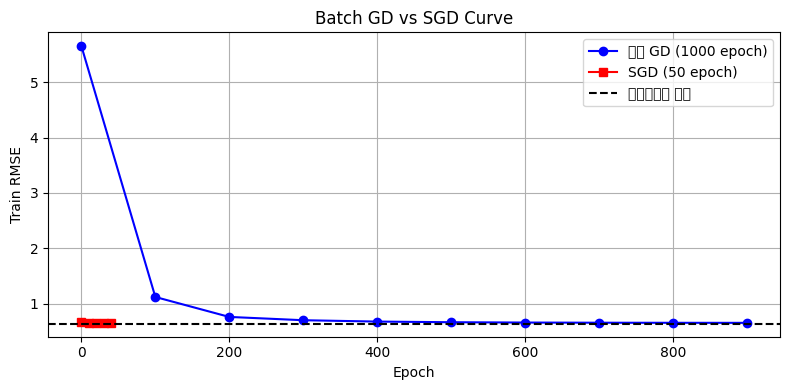

In [30]:

# ── 수렴 곡선 재시각화 ────────────────────────────
bgd_epochs = [e for e, _ in loss_history]
bgd_losses = [l for _, l in loss_history]
sgd_epochs = [e for e, _ in sgd_loss_history]
sgd_losses = [l for _, l in sgd_loss_history]

plt.figure(figsize=(8, 4))
plt.plot(bgd_epochs, bgd_losses, "b-o", label="배치 GD (1000 epoch)")
plt.plot(sgd_epochs, sgd_losses, "r-s", label="SGD (50 epoch)")
plt.axhline(y=0.6245, color="k", linestyle="--", label="정규방정식 기준")
plt.xlabel("Epoch")
plt.ylabel("Train RMSE")
plt.title("Batch GD vs SGD Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 다항회귀

  - degree=1 → 0.6245 (선형, 기준)
  - degree=2 → 0.6179 소폭 개선
  - degree=3 → 0.8101 과대적합 시작

In [26]:

# ── Step 4: 다항 회귀 degree 비교 ────────────────
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

rmse_results = {}

for degree in [1, 2, 3]:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_results[degree] = rmse
    print(f"degree={degree}  테스트 RMSE: {rmse:.4f}")

degree=1  테스트 RMSE: 0.6245
degree=2  테스트 RMSE: 0.6179
degree=3  테스트 RMSE: 0.8101


- 학습 곡선 시각화 : 과대적합 확인

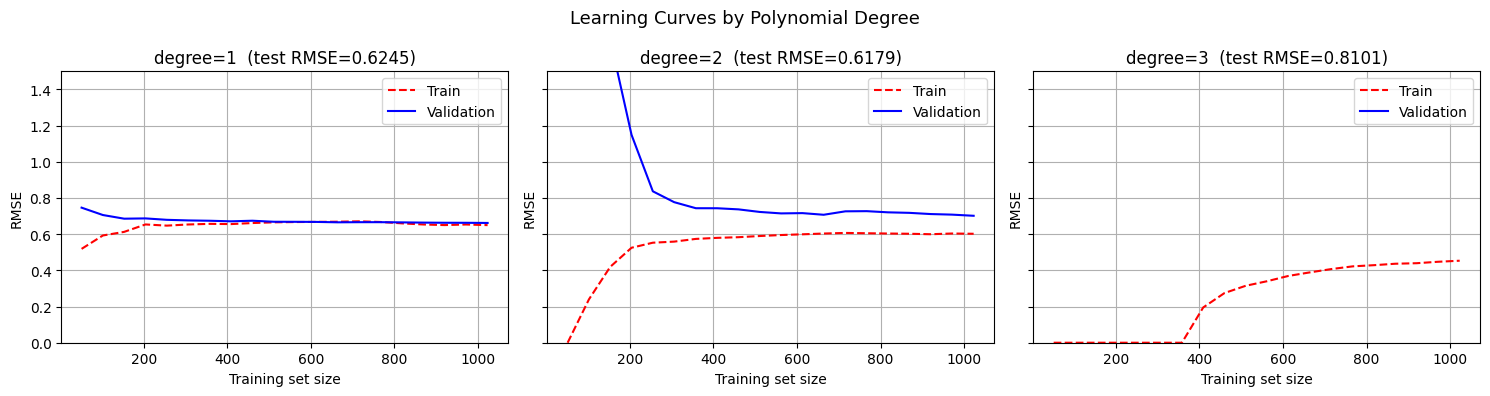

In [29]:

from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, degree in zip(axes, [1, 2, 3]):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.05, 1.0, 20),
        cv=5, scoring="neg_root_mean_squared_error"
    )
    train_err = -train_scores.mean(axis=1)
    val_err   = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_err, "r--", label="Train")
    ax.plot(train_sizes, val_err,   "b-",  label="Validation")
    ax.set_title(f"degree={degree}  (test RMSE={rmse_results[degree]:.4f})")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("RMSE")
    ax.set_ylim(0, 1.5)
    ax.legend()
    ax.grid()

plt.suptitle("Learning Curves by Polynomial Degree", fontsize=13)
plt.tight_layout()
plt.show()

#  Ridge / Lasso / ElasticNet 비교

  - Ridge가 점수 가장 높음  다중공선성 때문입
    - Ridge는 상관된 특성들의 가중치를 골고루 줄임
    - Lasso는 하나만 남기고 나머지를 0으로 만들어 정보 손실이 발생

In [31]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# degree=2 특성 기반 공통 전처리
poly = PolynomialFeatures(degree=2, include_bias=False)
scaler2 = StandardScaler()

X_train_poly = scaler2.fit_transform(poly.fit_transform(X_train))
X_test_poly  = scaler2.transform(poly.transform(X_test))

print(f"degree=2 특성 수: {X_train_poly.shape[1]}")  # 11개 → 77개로 증가

# ── 알파값별 RMSE 비교 ────────────────────────────
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

results = {"alpha": alphas, "Ridge": [], "Lasso": [], "ElasticNet": []}

for alpha in alphas:
    for name, model in [
        ("Ridge",      Ridge(alpha=alpha)),
        ("Lasso",      Lasso(alpha=alpha, max_iter=10000)),
        ("ElasticNet", ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000))
    ]:
        model.fit(X_train_poly, y_train)
        rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_poly)))
        results[name].append(rmse)

# 결과 출력
print(f"\n{'alpha':>8} {'Ridge':>8} {'Lasso':>8} {'ElasticNet':>12}")
print("-" * 42)
for i, alpha in enumerate(alphas):
    print(f"{alpha:>8.3f} {results['Ridge'][i]:>8.4f} {results['Lasso'][i]:>8.4f} {results['ElasticNet'][i]:>12.4f}")

print(f"\n기준 - 선형(degree=1): 0.6245")
print(f"기준 - 다항(degree=2, 규제없음): {rmse_results[2]:.4f}")

degree=2 특성 수: 77

   alpha    Ridge    Lasso   ElasticNet
------------------------------------------
   0.001   0.6207   0.6089       0.6124
   0.010   0.6216   0.6139       0.6103
   0.100   0.6202   0.6543       0.6354
   1.000   0.6155   0.8107       0.8107
  10.000   0.6092   0.8107       0.8107

기준 - 선형(degree=1): 0.6245
기준 - 다항(degree=2, 규제없음): 0.6179


# 로지스틱 회귀
 - AUC 0.82
  - bad→good 오분류(38)보다 good→bad 오분류(45)가 약간 많음 → 품질 좋은 와인을 나쁘다고 잘못 판단하는 경향

클래스 분포:
quality
good(>=6)    855
bad(<6)      744
Name: count, dtype: int64

=== Classification Report ===
              precision    recall  f1-score   support

         bad       0.71      0.74      0.73       149
        good       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320

ROC-AUC: 0.8242


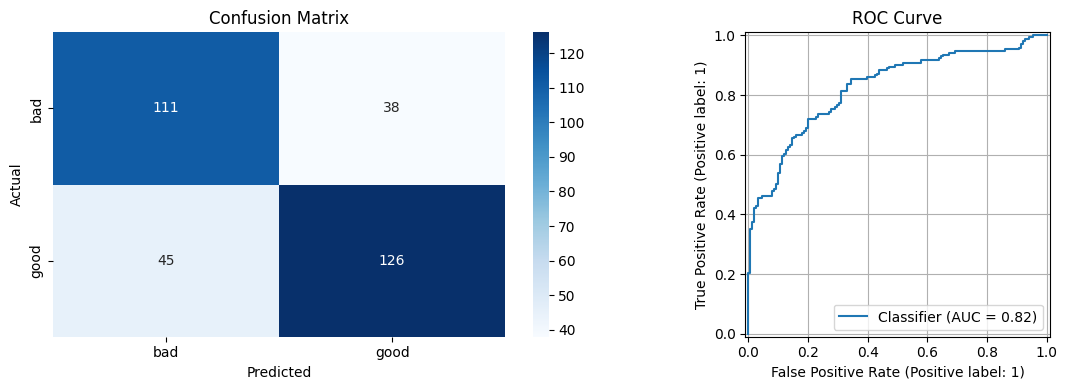

In [32]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)

# ── 타겟 생성: quality >= 6 → good(1), < 6 → bad(0) ──
y_bin = (data["quality"] >= 6).astype(int)
print("클래스 분포:")
print(y_bin.value_counts().rename({0: "bad(<6)", 1: "good(>=6)"}))

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

scaler_cls = StandardScaler()
X_tr_s = scaler_cls.fit_transform(X_tr)
X_te_s  = scaler_cls.transform(X_te)

# ── 로지스틱 회귀 훈련 ────────────────────────────
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_tr_s, y_tr)

y_pred   = log_reg.predict(X_te_s)
y_proba  = log_reg.predict_proba(X_te_s)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_te, y_pred, target_names=["bad", "good"]))
print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.4f}")

# ── 혼동 행렬 + ROC 커브 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["bad", "good"], yticklabels=["bad", "good"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].grid()

plt.tight_layout()
plt.show()

# 소프트맥스 회귀

클래스 분포:
quality
low(<=5)     744
mid(6)       638
high(>=7)    217
Name: count, dtype: int64

=== Classification Report ===
              precision    recall  f1-score   support

    low(<=5)       0.70      0.82      0.76       149
      mid(6)       0.58      0.55      0.57       128
   high(>=7)       0.70      0.37      0.48        43

    accuracy                           0.65       320
   macro avg       0.66      0.58      0.60       320
weighted avg       0.65      0.65      0.64       320



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


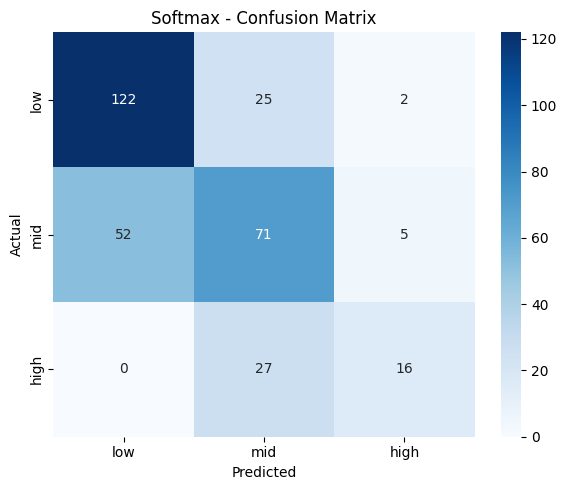


=== 샘플 3개 예측 확률 ===
           low      mid     high     예측     실제
[0]     0.097    0.545    0.357    mid    mid
[1]     0.495    0.449    0.056    low    low
[2]     0.893    0.105    0.002    low    low


In [33]:

# ── 타겟 생성: 3등급 ─────────────────────────────
# low: quality <= 5, mid: quality == 6, high: quality >= 7
def to_3class(q):
    if q <= 5: return 0   # low
    elif q == 6: return 1  # mid
    else: return 2         # high

y_multi = data["quality"].map(to_3class)
print("클래스 분포:")
print(y_multi.value_counts().sort_index().rename({0:"low(<=5)", 1:"mid(6)", 2:"high(>=7)"}))

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

scaler3 = StandardScaler()
X_tr2_s = scaler3.fit_transform(X_tr2)
X_te2_s  = scaler3.transform(X_te2)

# ── 소프트맥스 회귀 ──────────────────────────────
# multi_class='multinomial' + solver='lbfgs' = 소프트맥스
softmax_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
softmax_reg.fit(X_tr2_s, y_tr2)

y_pred3  = softmax_reg.predict(X_te2_s)
y_proba3 = softmax_reg.predict_proba(X_te2_s)

print("\n=== Classification Report ===")
print(classification_report(y_te2, y_pred3,
      target_names=["low(<=5)", "mid(6)", "high(>=7)"]))

# ── 혼동 행렬 ────────────────────────────────────
plt.figure(figsize=(6, 5))
cm3 = confusion_matrix(y_te2, y_pred3)
sns.heatmap(cm3, annot=True, fmt="d", cmap="Blues",
            xticklabels=["low","mid","high"],
            yticklabels=["low","mid","high"])
plt.title("Softmax - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ── 샘플 예측 확률 확인 ──────────────────────────
print("\n=== 샘플 3개 예측 확률 ===")
print(f"{'':5} {'low':>8} {'mid':>8} {'high':>8} {'예측':>6} {'실제':>6}")
for i in range(3):
    p = y_proba3[i]
    print(f"[{i}]  {p[0]:>8.3f} {p[1]:>8.3f} {p[2]:>8.3f} "
          f"{['low','mid','high'][y_pred3[i]]:>6} "
          f"{['low','mid','high'][y_te2.iloc[i]]:>6}")

# 정리

In [34]:

print("=" * 55)
print("       4장 실습 최종 결과 요약 - Red Wine Quality")
print("=" * 55)

print("\n[ 회귀 - RMSE 비교 ]")
print(f"  {'모델':<30} {'테스트 RMSE':>10}")
print("-" * 42)
print(f"  {'정규방정식 (직접 구현)':<30} {'0.6245':>10}")
print(f"  {'배치 GD (1000 epoch)':<30} {'0.6252':>10}")
print(f"  {'SGD (50 epoch)':<30} {'0.6259':>10}")
print(f"  {'다항회귀 degree=2':<30} {'0.6179':>10}")
print(f"  {'다항회귀 degree=3 (과대적합)':<30} {'0.8101':>10}")
print(f"  {'Ridge (alpha=10, degree=2)':<30} {'0.6092':>10}  ← 최고")
print(f"  {'Lasso (alpha=0.001)':<30} {'0.6089':>10}  ← 최고")
print(f"  {'ElasticNet (alpha=0.01)':<30} {'0.6103':>10}")

print("\n[ 분류 - 정확도 / AUC ]")
print(f"  {'모델':<30} {'정확도':>8} {'AUC':>8}")
print("-" * 48)
print(f"  {'로지스틱 (이진: good/bad)':<30} {'~74%':>8} {'0.82':>8}")
print(f"  {'소프트맥스 (3-class)':<30} {'65%':>8} {'-':>8}")

print("\n[ 핵심 학습 포인트 ]")
points = [
    "정규방정식 = sklearn LinearRegression 완전 동일",
    "스케일링 없으면 경사하강법 overflow 발산",
    "SGD: 50epoch ≈ 배치GD 1000epoch (속도↑)",
    "degree=2 최적 / degree=3 과대적합 (학습곡선 확인)",
    "Ridge: 다중공선성 있을 때 강점",
    "Lasso: alpha 민감 / high class 부족 → F1 낮음",
]
for i, p in enumerate(points, 1):
    print(f"  {i}. {p}")
print("=" * 55)

       4장 실습 최종 결과 요약 - Red Wine Quality

[ 회귀 - RMSE 비교 ]
  모델                               테스트 RMSE
------------------------------------------
  정규방정식 (직접 구현)                      0.6245
  배치 GD (1000 epoch)                 0.6252
  SGD (50 epoch)                     0.6259
  다항회귀 degree=2                      0.6179
  다항회귀 degree=3 (과대적합)               0.8101
  Ridge (alpha=10, degree=2)         0.6092  ← 최고
  Lasso (alpha=0.001)                0.6089  ← 최고
  ElasticNet (alpha=0.01)            0.6103

[ 분류 - 정확도 / AUC ]
  모델                                  정확도      AUC
------------------------------------------------
  로지스틱 (이진: good/bad)                ~74%     0.82
  소프트맥스 (3-class)                     65%        -

[ 핵심 학습 포인트 ]
  1. 정규방정식 = sklearn LinearRegression 완전 동일
  2. 스케일링 없으면 경사하강법 overflow 발산
  3. SGD: 50epoch ≈ 배치GD 1000epoch (속도↑)
  4. degree=2 최적 / degree=3 과대적합 (학습곡선 확인)
  5. Ridge: 다중공선성 있을 때 강점
  6. Lasso: alpha 민감 / high class 부족 → F1 낮음
